# Воспроизведение методики Chulkov et al. (2019)
### Оценка глубины дефектов по ИК-термографии с предобработкой данных для нейросети

Ноутбук воспроизводит методологию статьи:

> **A.O. Chulkov et al.** «Optimizing input data for training an artificial neural network
> used for evaluating defect depth in infrared thermographic nondestructive testing»,
> *Infrared Physics & Technology*, 2019.

**Задача.** На образце находятся плоскодонные дефекты на разных глубинах
(**0.5 … 2.5 мм**, 5 глубин). Образец импульсно нагревают, регистрируют ИК-видео
остывания. Над более мелким дефектом теплоотвод вглубь затруднён — поверхность
дольше остаётся тёплой, поэтому дефект проявляется как более «горячее» пятно.
Динамика температуры в точке несёт информацию о **глубине** дефекта.

**Цель работы статьи** — сравнить 8 (+варианты) способов предобработки температурной
последовательности (Seq 1–8) и понять, какой из них даёт наименьшую ошибку σ/h при
обучении нейросети предсказывать глубину. В статье лучшей оказалась **Seq 5 (TSR,
первая производная)** с σ/h ≈ 1 %.

> ⚠️ В используемом `.mat`-файле нет меток глубины дефектов, поэтому соответствие
> «дефект ↔ глубина» задаётся ниже как **настраиваемая константа**. Воспроизводится
> именно *конвейер обработки и обучения*, а не абсолютная привязка к конкретному образцу.


## 1. Импорты и константы

In [1]:
# Базовые библиотеки
import os, warnings
import numpy as np
import scipy.io as sio
from scipy import ndimage, signal
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.colors import Normalize

# Машинное обучение
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Видео / интерактив (опционально)
try:
    import cv2                      # noqa
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False
try:
    from ipywidgets import interact, IntSlider
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)
print("cv2:", HAS_CV2, "| ipywidgets:", HAS_WIDGETS)

cv2: True | ipywidgets: True


### Константы эксперимента (меняются в одном месте)

In [2]:
# ── Путь к готовой видеопоследовательности ──────────────────────────────────
DATA_FILE = "dataset_tpu/Sample 11 Static.mat"   # (H, W, n_frames), калибровано в °C

# ── Частота записи. В файле FPS не задан (=0), поэтому используем значение ниже ─
FPS_DEFAULT = 27.0        # Гц; подставьте реальную частоту камеры, если известна

# ── Глубины 5 дефектов D1..D5 (мм) ──────────────────────────────────────────
DEFECT_DEPTHS_MM = [0.5, 1.0, 1.5, 2.0, 2.5]      # D1 самый мелкий … D5 самый глубокий

# ── Центры дефектов (row, col) в порядке D1..D5. По умолчанию — из авто-детекции
#    (см. раздел 5). Задаётся как константа; при желании переопределите вручную. ─
DEFECT_CENTERS = [(85, 274), (82, 191), (80, 107), (79, 35), (146, 105)]

# ── Экономия памяти: пространственное прореживание кадра в DOWNSCALE раз ──────
#    (2 → в 4 раза меньше памяти/времени; поставьте 1 для полного разрешения) ─
DOWNSCALE      = 2

# ── Параметры предобработки ─────────────────────────────────────────────────
EXP_ALPHA      = 0.15     # коэффициент экспоненциального сглаживания (Seq 1)
MEDIAN_KSIZE   = 3        # пространственный медианный фильтр 3×3 (Seq 1)
POLY_DEGREE    = 5        # степень полинома лог-аппроксимации (Seq 4)
PCA_TIME_STRIDE = 4       # прореживание по времени для PCA (Seq 7), для скорости
FFT_BIN        = 3        # номер низкой значимой частоты для фазограммы (Seq 8)

# ── Выборка точек для обучения NN (как в статье, Fig. 4) ────────────────────
N_TRAIN_PER_DEF = 12      # обучающих точек на дефект
N_VAL_PER_DEF   = 4       # валидационных дефектных точек на дефект (+ столько же фона)
FEATURE_LEN     = 32      # длина признакового вектора (ресемплинг температурной кривой)

# ── Экспорт видео ───────────────────────────────────────────────────────────
VIDEO_STRIDE = 8          # брать каждый VIDEO_STRIDE-й кадр при экспорте (для скорости)
OUT_DIR = "seq_videos"; os.makedirs(OUT_DIR, exist_ok=True)

N_DEF = len(DEFECT_DEPTHS_MM)
print("Дефектов:", N_DEF, "| глубины, мм:", DEFECT_DEPTHS_MM)

Дефектов: 5 | глубины, мм: [0.5, 1.0, 1.5, 2.0, 2.5]


## 2. Загрузка готовой видеопоследовательности

Файл содержит переменную `data` формы `(H, W, n_frames)` в °C. Приводим к
удобному виду `X = (n_frames, H, W)` и извлекаем ось времени.

In [3]:
def load_sequence(path, fps_default=FPS_DEFAULT):
    m = sio.loadmat(path)
    # имя массива может отличаться в разных наборах — ищем 3D-переменную
    key = next(k for k in ("data", "imageArray", "IMAGES")
               if k in m and np.asarray(m[k]).ndim == 3)
    d = np.asarray(m[key]).astype(np.float32)        # (H, W, n)
    X = np.transpose(d, (2, 0, 1)).copy()            # (n, H, W)
    fps = 0.0
    for fk in ("FPS", "Fs", "fps"):
        if fk in m:
            v = np.ravel(m[fk])
            try: fps = float(v[0]) if not isinstance(v[0], (bytes, str, np.str_)) \
                        else float("".join(np.ravel(m[fk]).astype(str)))
            except Exception: fps = 0.0
            break
    if fps <= 0: fps = fps_default
    return X, fps

X, FPS = load_sequence(DATA_FILE)
# Прореживаем по пространству для экономии памяти (все стеки станут в DS^2 меньше)
if DOWNSCALE > 1:
    X = X[:, ::DOWNSCALE, ::DOWNSCALE].copy()
N, H, W = X.shape
t = np.arange(N) / FPS                                # ось времени, с

# Центры дефектов пересчитываем под текущее разрешение
CENTERS = [(r // DOWNSCALE, c // DOWNSCALE) for (r, c) in DEFECT_CENTERS]
OFF_BG  = max(4, 22 // DOWNSCALE)                     # сдвиг к фоновой точке, пикс.

print(f"Файл           : {DATA_FILE}")
print(f"Кадров         : {N}")
print(f"Размер кадра   : {H} × {W}  (downscale ×{DOWNSCALE})")
print(f"Частота (исп.) : {FPS:g} Гц  →  длительность {t[-1]:.1f} с")
print(f"Диапазон T     : {X.min():.2f} … {X.max():.2f} °C")
print(f"Центры дефектов (масштаб.): {CENTERS}")

Файл           : dataset_tpu/Sample 11 Static.mat
Кадров         : 2000
Размер кадра   : 120 × 160  (downscale ×2)
Частота (исп.) : 27 Гц  →  длительность 74.0 с
Диапазон T     : 19.07 … 61.12 °C
Центры дефектов (масштаб.): [(42, 137), (41, 95), (40, 53), (39, 17), (73, 52)]


### Момент импульса нагрева и фаза остывания

Пик нагрева: кадр 185 (t=6.85 c), далее — остывание


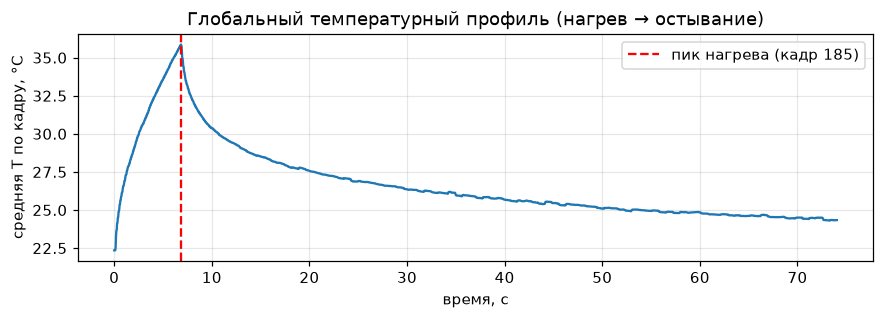

In [4]:
# Средняя по кадру температура во времени — по ней находим пик нагрева
mean_curve = X.reshape(N, -1).mean(axis=1)
PEAK = int(np.argmax(mean_curve))          # кадр максимума нагрева
print(f"Пик нагрева: кадр {PEAK} (t={t[PEAK]:.2f} c), далее — остывание")

plt.figure(figsize=(8, 3))
plt.plot(t, mean_curve, lw=1.5)
plt.axvline(t[PEAK], color="r", ls="--", label=f"пик нагрева (кадр {PEAK})")
plt.xlabel("время, с"); plt.ylabel("средняя T по кадру, °C")
plt.title("Глобальный температурный профиль (нагрев → остывание)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Несколько сырых кадров

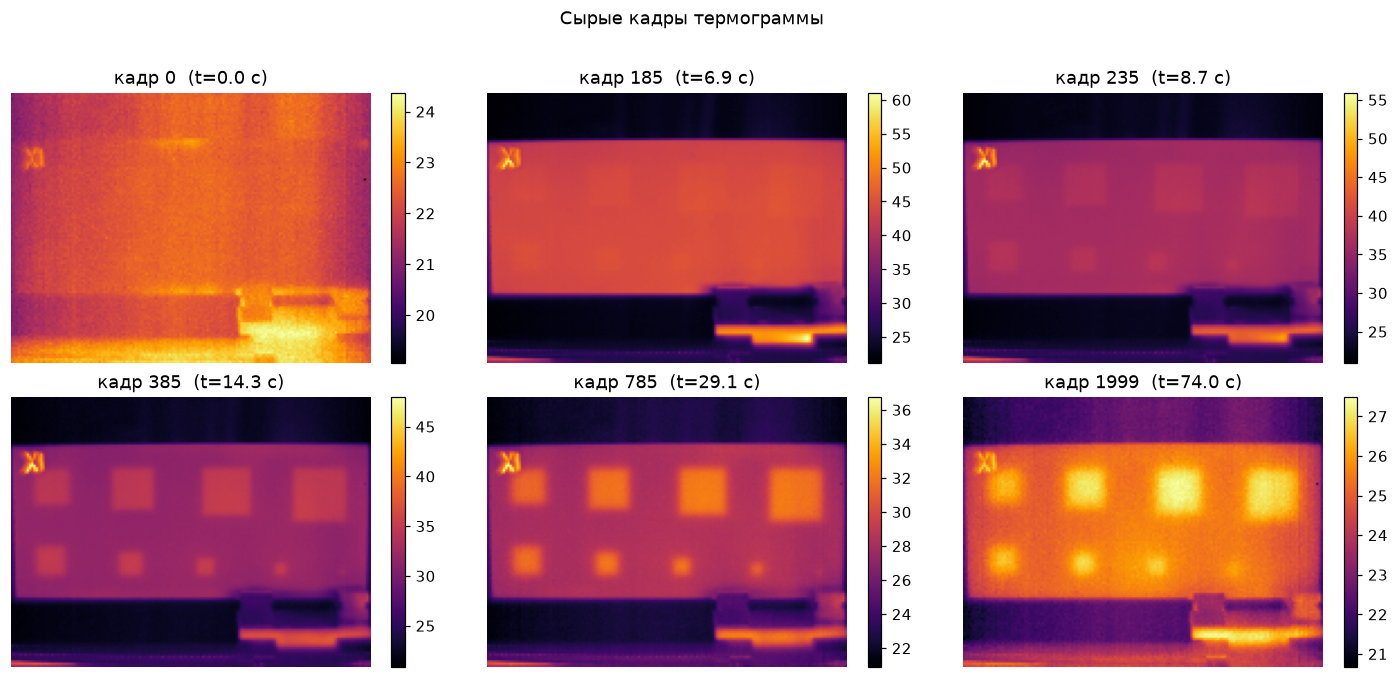

In [5]:
frames_show = [0, PEAK, PEAK + 50, PEAK + 200, PEAK + 600, N - 1]
fig, axs = plt.subplots(2, 3, figsize=(13, 6))
for ax, fi in zip(axs.ravel(), frames_show):
    im = ax.imshow(X[fi], cmap="inferno")
    ax.set_title(f"кадр {fi}  (t={t[fi]:.1f} c)"); ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Сырые кадры термограммы", y=1.02)
plt.tight_layout(); plt.show()

### Служебные величины: избыточная температура ΔT и фаза остывания

- **Базовая линия** `T0` — средняя температура по первым кадрам до нагрева
  (пиксельно). **Избыточная температура** ΔT(t) = T(t) − T0.
- Многие преобразования работают только на **фазе остывания** `t ≥ t_peak`.

In [6]:
BASE_FRAMES = max(1, PEAK // 4)                       # кадры до нагрева для базы
T0 = X[:BASE_FRAMES].mean(axis=0)                    # (H, W) базовая линия
dT = X - T0[None]                                    # (n, H, W) избыточная T

# Фаза остывания и её локальная ось времени (сдвиг, чтобы log(t) был определён)
COOL = slice(PEAK, N)
Xc   = X[COOL]                                       # (nc, H, W)
dTc  = np.clip(dT[COOL], 1e-3, None)                 # ΔT>0 для логарифма
tc   = (np.arange(Xc.shape[0]) + 1) / FPS            # локальное время остывания, с
nc   = Xc.shape[0]
print("Кадров остывания:", nc)

Кадров остывания: 1815


## 3. Реализация 8 способов предобработки (Seq 1–8)

Каждая функция принимает массивы уровня всего кадра и возвращает обработанную
последовательность/карту. Ниже — реализация, затем визуализация по образцу
Fig. 3 / Fig. 6 / Fig. 7 статьи:
* **(а)** карта-изображение (`imshow`) в характерный момент;
* **(б)** сигнал в точке дефекта против бездефектной зоны, для всех 5 глубин.

Договорённости о выходе: функции с временной динамикой возвращают стек
`(n', H, W)`; чисто «сжимающие» преобразования (PCA, фазограмма) — карту `(H, W)`.

### Seq 1 — сырые данные + временной и пространственный фильтры

In [7]:
def seq1(X, alpha=EXP_ALPHA, ksize=MEDIAN_KSIZE):
    '''Экспоненциальное сглаживание по времени (IIR) + медианный фильтр 3×3.'''
    # y[i] = alpha*x[i] + (1-alpha)*y[i-1]  — рекурсивный фильтр по оси времени
    b, a = [alpha], [1.0, -(1.0 - alpha)]
    Y = signal.lfilter(b, a, X, axis=0).astype(np.float32)
    Y = ndimage.median_filter(Y, size=(1, ksize, ksize))   # пространственный 3×3
    return Y

S1 = seq1(X)
print("Seq1:", S1.shape)

Seq1: (2000, 120, 160)


### Seq 2 — обрезка фазы нагрева (только остывание)

In [8]:
def seq2(X, peak=PEAK):
    '''Оставляем только участок остывания t >= t_peak.'''
    return X[peak:].copy()

S2 = seq2(X)
print("Seq2:", S2.shape, "(было", X.shape[0], "кадров)")

Seq2: (1815, 120, 160) (было 2000 кадров)


### Seq 3 — логарифмические координаты log(t), log(ΔT)

In [9]:
def seq3(dTc, tc):
    '''Переход к координатам (log t, log ΔT) на фазе остывания.'''
    logt  = np.log(tc)                                # (nc,)
    logdT = np.log(dTc)                               # (nc, H, W)
    return logt, logdT

LOGT, S3 = seq3(dTc, tc)
print("Seq3: logt", LOGT.shape, "logdT", S3.shape)

Seq3: logt (1815,) logdT (1815, 120, 160)


### Seq 4 — полиномиальная аппроксимация 5-й степени лог-кривой (TSR-база)

Для каждого пикселя аппроксимируем `log ΔT` полиномом 5-й степени от `log t`
(метод Thermographic Signal Reconstruction). `numpy.polyfit` векторизуется:
одна матрица Вандермонда — все пиксели сразу.

In [10]:
def fit_tsr(logt, logdT, deg=POLY_DEGREE):
    '''Возвращает коэффициенты полинома (deg+1, H, W).'''
    nc, H, W = logdT.shape
    Y = logdT.reshape(nc, -1)                         # (nc, H*W)
    coef = np.polyfit(logt, Y, deg)                   # (deg+1, H*W)
    return coef.reshape(deg + 1, H, W)

def poly_eval(coef, logt):
    '''Восстановление стека по коэффициентам: (n, H, W).'''
    dp1, H, W = coef.shape
    V = np.vander(logt, dp1)                          # (n, deg+1)
    flat = V @ coef.reshape(dp1, -1)                  # (n, H*W)
    return flat.reshape(len(logt), H, W)

COEF = fit_tsr(LOGT, S3)                              # база для Seq4/5/6
S4   = poly_eval(COEF, LOGT)                          # сглаженный log ΔT
print("Seq4: coef", COEF.shape, "-> stack", S4.shape)

Seq4: coef (6, 120, 160) -> stack (1815, 120, 160)


### Seq 4′ — бегущий контраст C = ΔT/T_nd, нормированный по максимуму

In [11]:
def sound_curve(dTc, centers, r=6):
    '''Опорная бездефектная кривая: медиана ΔT по «здоровым» зонам между дефектами.'''
    H, W = dTc.shape[1:]
    mask = np.ones((H, W), bool)
    for (rr, cc) in centers:                          # вырезаем окрестности дефектов
        r0, r1 = max(0, rr-2*r), min(H, rr+2*r)
        c0, c1 = max(0, cc-2*r), min(W, cc+2*r)
        mask[r0:r1, c0:c1] = False
    return np.median(dTc[:, mask], axis=1)            # (nc,) опорная T_nd(t)

def seq4_contrast(dTc, centers, normalize=True):
    '''Бегущий температурный контраст C(t) = ΔT(t)/T_nd(t).'''
    Tnd = sound_curve(dTc, centers)[:, None, None]    # (nc,1,1)
    C = dTc / Tnd
    if normalize:                                     # нормировка по максимуму во времени
        C = C / np.clip(C.max(axis=0, keepdims=True), 1e-6, None)
    return C.astype(np.float32)

S4p  = seq4_contrast(dTc, CENTERS, normalize=True)   # Seq 4′
S4pp = seq4_contrast(dTc, CENTERS, normalize=False)  # Seq 4″
print("Seq4′:", S4p.shape, "| Seq4″:", S4pp.shape)

Seq4′: (1815, 120, 160) | Seq4″: (1815, 120, 160)


### Seq 5 и Seq 6 — 1-я и 2-я производные Seq 4 (TSR-производные)

In [ ]:
def poly_derivative(coef, order=1):
    '''Коэффициенты производной полинома order-го порядка (по log t).'''
    dp1 = coef.shape[0]
    powers = np.arange(dp1 - 1, -1, -1)               # степени при коэффициентах
    c = coef.copy()
    for _ in range(order):
        c = c[:-1] * powers[:-1].reshape(-1, *[1]*(c.ndim-1))
        powers = powers[:-1] - 1
        powers = np.arange(c.shape[0] - 1, -1, -1)
    return c

def seq_derivative(coef, logt, order=1):
    dcoef = poly_derivative(coef, order)
    return poly_eval(dcoef, logt)

S5 = seq_derivative(COEF, LOGT, 1)                    # первая производная (TSR)
S6 = seq_derivative(COEF, LOGT, 2)                    # вторая производная
print("Seq5:", S5.shape, "| Seq6:", S6.shape)

Seq5: (1815, 120, 160) | Seq6: (1815, 120, 160)


### Seq 7 — PCA по временной оси (первая главная компонента)

In [13]:
def seq7_pca(Xc, stride=PCA_TIME_STRIDE, n_comp=3):
    '''PCA: объекты — пиксели, признаки — время (прорежено). Возврат карт компонент.'''
    nc, H, W = Xc.shape
    M = Xc[::stride].reshape(-1, H*W).T.astype(np.float32)   # (пиксели, время)
    pca = PCA(n_components=n_comp, svd_solver="randomized", random_state=0)
    scores = pca.fit_transform(M)                     # (пиксели, n_comp)
    maps = scores.T.reshape(n_comp, H, W)
    return maps, pca

S7_maps, pca7 = seq7_pca(Xc)
S7 = S7_maps[0]                                       # 1-я главная компонента (карта)
print("Seq7: карты", S7_maps.shape, "| дисперсия PC1..3 =",
      np.round(pca7.explained_variance_ratio_[:3], 3))

Seq7: карты (3, 120, 160) | дисперсия PC1..3 = [0.98  0.017 0.002]


### Seq 8 — Фурье-фазограмма (фаза на низкой значимой частоте)

In [14]:
def seq8_phase(dTc, k=FFT_BIN):
    '''Фаза БПФ на частотном бине k (Pulse Phase Thermography).'''
    F = np.fft.rfft(dTc, axis=0)                      # (nf, H, W) комплексный
    phase = np.angle(F[k])                            # фазовая карта на бине k
    return phase.astype(np.float32), F

S8, FFT = seq8_phase(dTc)
print("Seq8: фазовая карта", S8.shape, "на бине k =", FFT_BIN)

Seq8: фазовая карта (120, 160) на бине k = 3


### Единый реестр последовательностей и функции визуализации

Складываем все Seq в словарь: для каждого храним стек/карту, характерный кадр
и подпись. Далее — общие функции для карт (Fig. 3/7) и кривых в точках (Fig. 6/7).

In [15]:
# Характерный кадр остывания для показа карт
SHOW_F = min(600, nc - 1)

SEqS = {
    "Seq1":  dict(kind="stack", data=S1[COOL],  frame=SHOW_F, title="Seq1: фильтры"),
    "Seq2":  dict(kind="stack", data=S2,        frame=SHOW_F, title="Seq2: только остывание"),
    "Seq3":  dict(kind="stack", data=S3,        frame=SHOW_F, title="Seq3: log ΔT"),
    "Seq4":  dict(kind="stack", data=S4,        frame=SHOW_F, title="Seq4: полином 5° (TSR)"),
    "Seq4'": dict(kind="stack", data=S4p,       frame=SHOW_F, title="Seq4′: контраст (норм.)"),
    "Seq4''":dict(kind="stack", data=S4pp,      frame=SHOW_F, title="Seq4″: контраст"),
    "Seq5":  dict(kind="stack", data=S5,        frame=SHOW_F, title="Seq5: 1-я произв. (TSR)"),
    "Seq6":  dict(kind="stack", data=S6,        frame=SHOW_F, title="Seq6: 2-я произв."),
    "Seq7":  dict(kind="map",   data=S7,        frame=None,   title="Seq7: PCA (PC1)"),
    "Seq8":  dict(kind="map",   data=S8,        frame=None,   title="Seq8: фазограмма"),
}
SEQ_ORDER = list(SEqS.keys())

def seq_map(name):
    '''Возвращает 2D-карту для показа: кадр стека или готовую карту.'''
    s = SEqS[name]
    return s["data"] if s["kind"] == "map" else s["data"][s["frame"]]

def seq_point_curve(name, r, c):
    '''Временная кривая в точке (r,c); для карт — окрестность как «профиль».'''
    s = SEqS[name]
    if s["kind"] == "map":
        rr = slice(max(0, r-1), r+2); cc = slice(max(0, c-1), c+2)
        return s["data"][rr, cc].ravel()
    return s["data"][:, r, c]

#### (а) Карты всех Seq в характерный момент (обзор, аналог Fig. 3/Fig. 7)

#### (б) Сигнал в точке дефекта vs фон, для всех 5 глубин

Для каждого дефекта берём его центр (дефектная точка) и ближайшую бездефектную
точку. Цвет кривой = глубина дефекта (как в Fig. 6/7). Для стеков — кривая во
времени; для карт (Seq7/8) выводим значение-профиль окрестности.

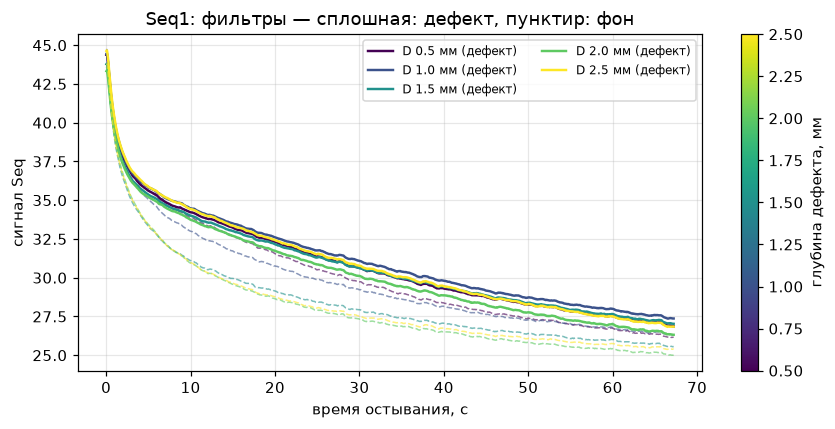

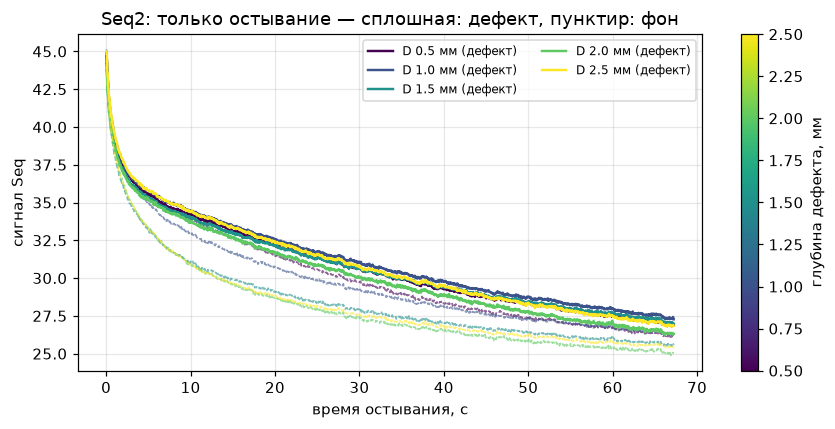

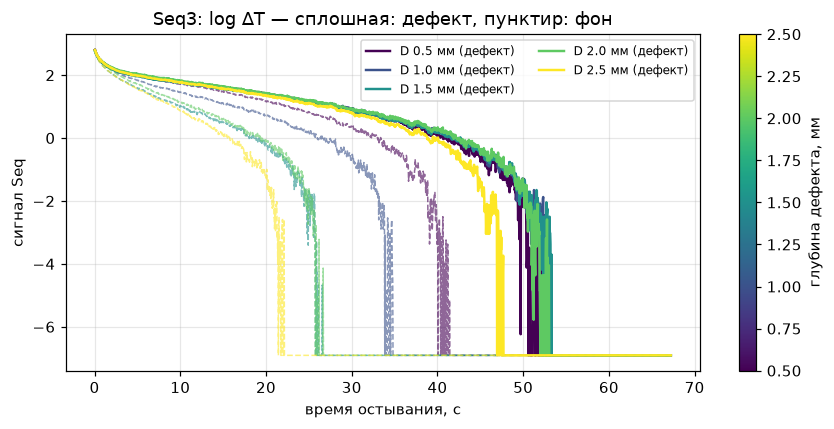

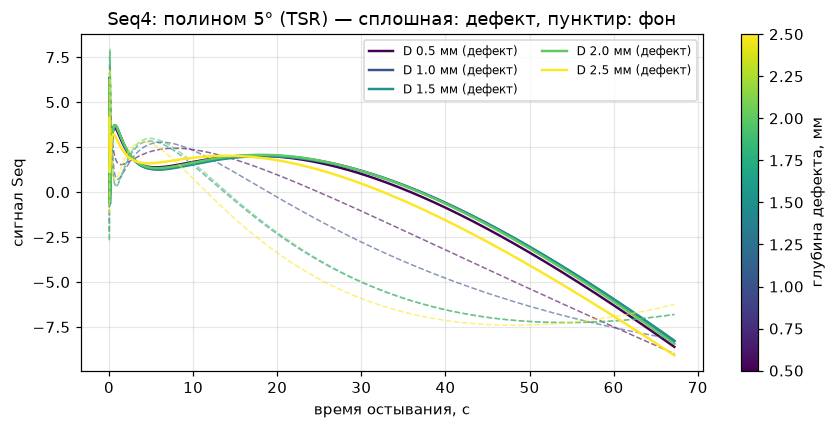

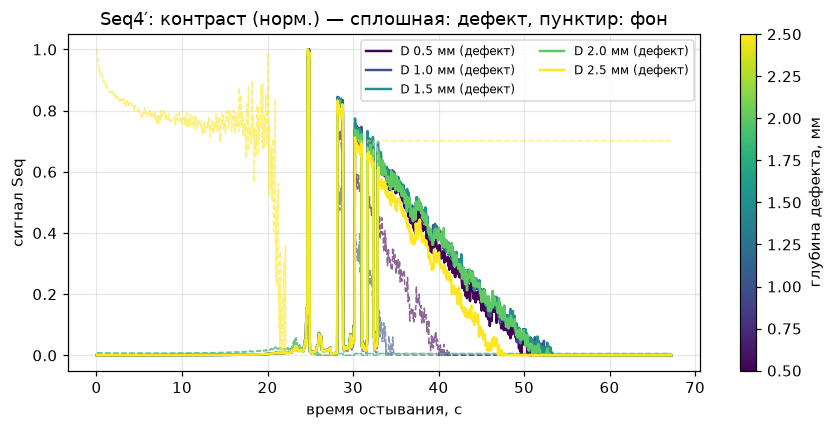

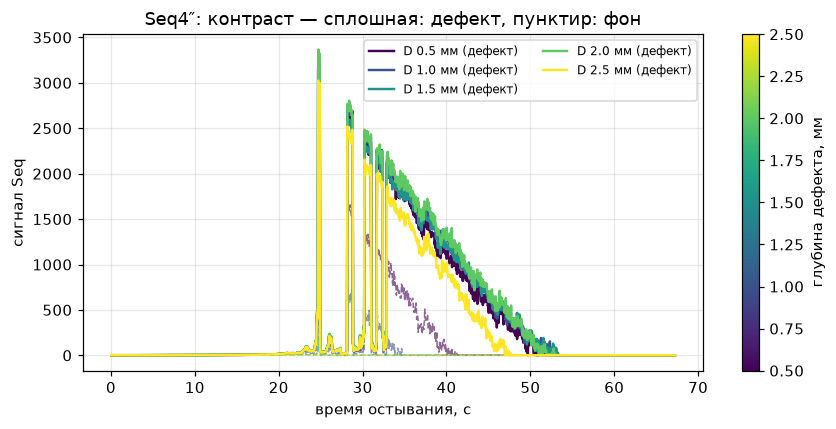

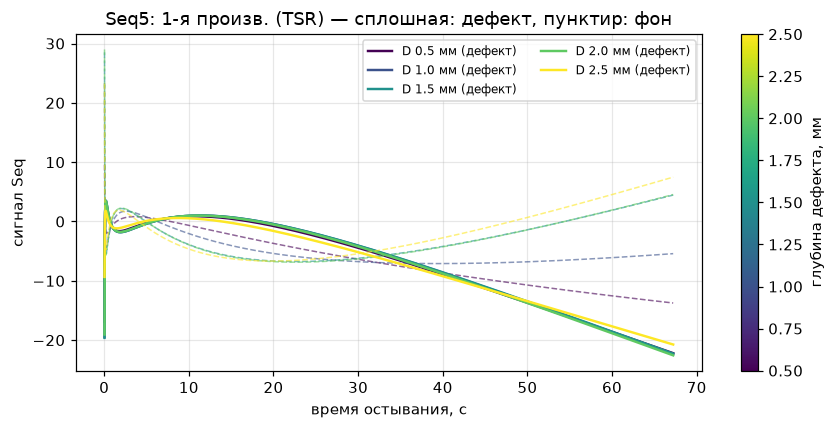

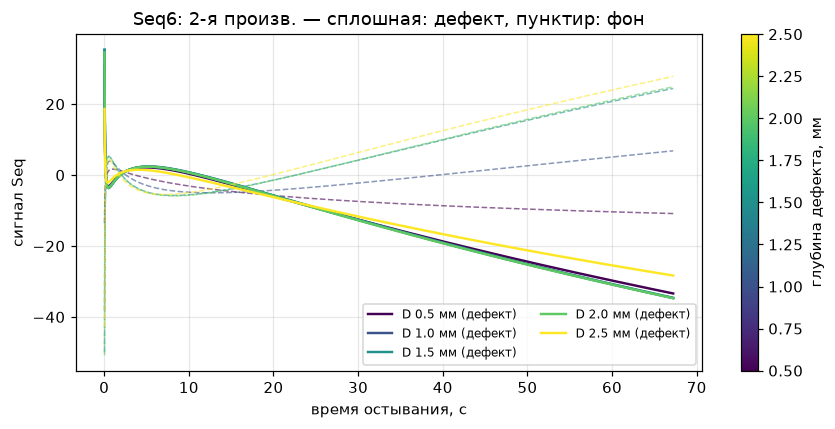

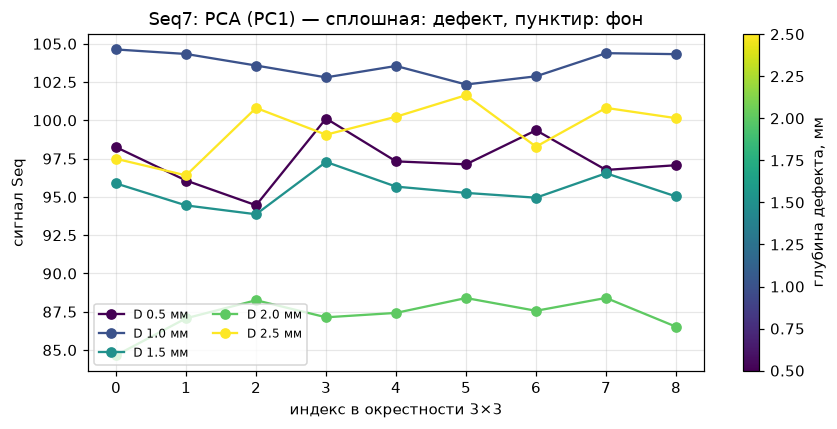

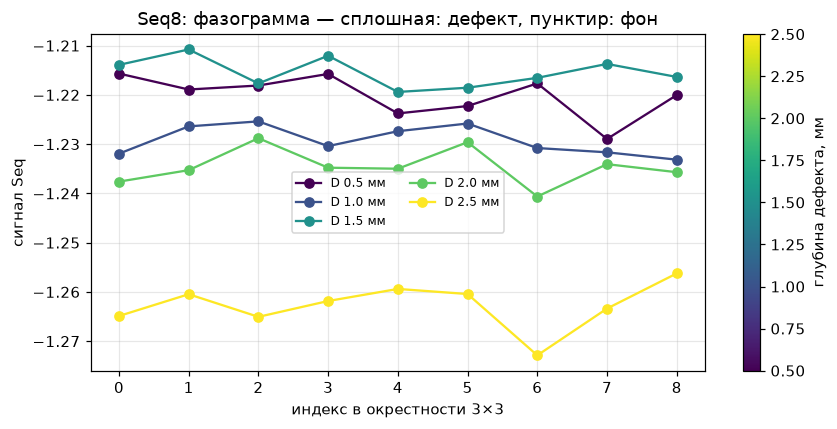

In [17]:
def sound_point_for(r, c, off=None):
    '''Бездефектная точка рядом с дефектом (сдвиг вниз, если в кадре).'''
    if off is None: off = OFF_BG
    return (min(H-1, r+off), c)

cmap_depth = plt.cm.viridis
norm_depth = Normalize(vmin=min(DEFECT_DEPTHS_MM), vmax=max(DEFECT_DEPTHS_MM))

def plot_curves_for_seq(name):
    s = SEqS[name]
    fig, ax = plt.subplots(figsize=(8, 4))
    for (r, c), h in zip(CENTERS, DEFECT_DEPTHS_MM):
        col = cmap_depth(norm_depth(h))
        yd = seq_point_curve(name, r, c)
        rs, cs = sound_point_for(r, c)
        yn = seq_point_curve(name, rs, cs)
        if s["kind"] == "stack":
            xx = tc if len(yd) == nc else np.arange(len(yd)) / FPS
            ax.plot(xx, yd, color=col, lw=1.6, label=f"D {h} мм (дефект)")
            ax.plot(xx, yn, color=col, lw=1.0, ls="--", alpha=0.6)
            ax.set_xlabel("время остывания, с")
        else:
            ax.plot(np.arange(len(yd)), yd, "o-", color=col, label=f"D {h} мм")
            ax.set_xlabel("индекс в окрестности 3×3")
    ax.set_title(f"{SEqS[name]['title']} — сплошная: дефект, пунктир: фон")
    ax.set_ylabel("сигнал Seq"); ax.grid(alpha=0.3)
    sm = plt.cm.ScalarMappable(norm=norm_depth, cmap=cmap_depth); sm.set_array([])
    fig.colorbar(sm, ax=ax, label="глубина дефекта, мм")
    ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

for nm in SEQ_ORDER:
    plot_curves_for_seq(nm)

## 4. Интерактивная визуализация по кадрам и экспорт видео

### Слайдер прокрутки кадров (по каждой Seq со стеком)

In [30]:
STACK_SEQS = [n for n in SEQ_ORDER if SEqS[n]["kind"] == "stack"]

def show_frame(seq_name="Seq5", frame=0):
    data = SEqS[seq_name]["data"]
    frame = min(frame, data.shape[0]-1)
    plt.figure(figsize=(6, 4.5))
    plt.imshow(data[frame], cmap="inferno")
    plt.title(f"{SEqS[seq_name]['title']} — кадр {frame}"); plt.axis("off")
    plt.colorbar(fraction=0.046); plt.show()

if HAS_WIDGETS:
    interact(show_frame,
             seq_name=STACK_SEQS,
             frame=IntSlider(min=0, max=nc-1, step=5, value=SHOW_F))
else:
    print("ipywidgets недоступен — показываю статический кадр:")
    show_frame("Seq5", SHOW_F)

interactive(children=(Dropdown(description='seq_name', index=6, options=('Seq1', 'Seq2', 'Seq3', 'Seq4', "Seq4…

### Экспорт каждой Seq в видео (.mp4 или .gif)

In [19]:
def export_seq_video(seq_name, out_path=None, stride=VIDEO_STRIDE, fps=15):
    '''Сохраняет стек Seq как видео. Карты (Seq7/8) пропускаются.'''
    s = SEqS[seq_name]
    if s["kind"] != "stack":
        print(f"{seq_name}: карта, видео не требуется"); return None
    data = s["data"][::stride]
    vmin, vmax = np.percentile(data, [1, 99])
    fig, ax = plt.subplots(figsize=(5, 4)); ax.axis("off")
    im = ax.imshow(data[0], cmap="inferno", vmin=vmin, vmax=vmax)
    ttl = ax.set_title(f"{s['title']} — 0")
    def upd(i):
        im.set_data(data[i]); ttl.set_text(f"{s['title']} — {i*stride}")
        return im, ttl
    anim = animation.FuncAnimation(fig, upd, frames=len(data), blit=False)
    if out_path is None:
        out_path = os.path.join(OUT_DIR, f"{seq_name.replace(chr(39),'p')}.gif")
    try:
        if out_path.endswith(".mp4"):
            anim.save(out_path, writer=animation.FFMpegWriter(fps=fps))
        else:
            anim.save(out_path, writer=animation.PillowWriter(fps=fps))
    finally:
        plt.close(fig)
    print("сохранено:", out_path); return out_path

# Пример: экспорт одной наглядной последовательности
export_seq_video("Seq5", os.path.join(OUT_DIR, "Seq5.gif"))

сохранено: seq_videos/Seq5.gif


'seq_videos/Seq5.gif'

### Сводная сетка 2×4 с синхронной анимацией всех Seq (общий слайдер кадра)

Наглядное сравнение «какая предобработка ярче показывает дефект» в один момент времени.

In [ ]:
GRID_SEQS = STACK_SEQS[:8]                 # до 8 стек-последовательностей в сетку 2×4
def show_grid(frame=SHOW_F):
    fig, axs = plt.subplots(2, 4, figsize=(16, 7))
    for ax, name in zip(axs.ravel(), GRID_SEQS):
        d = SEqS[name]["data"]; fi = min(frame, d.shape[0]-1)
        vmin, vmax = np.percentile(d[fi], [1, 99])
        ax.imshow(d[fi], cmap="inferno", vmin=vmin, vmax=vmax)
        ax.set_title(f"{SEqS[name]['title']}\n(кадр {fi})", fontsize=9); ax.axis("off")
    fig.suptitle(f"Синхронное сравнение Seq — кадр {frame}", y=1.02)
    plt.tight_layout(); plt.show()

if HAS_WIDGETS:
    interact(show_grid, frame=IntSlider(min=0, max=nc-1, step=10, value=SHOW_F))
else:
    show_grid(SHOW_F)

interactive(children=(IntSlider(value=600, description='frame', max=1814, step=10), Output()), _dom_classes=('…

## 5. Извлечение точек и формирование выборки для нейросети

Повторяем логику Fig. 4 статьи **программно**:
* находим центры дефектов авто-детекцией по карте контраста (для проверки/переопределения
  константы `DEFECT_CENTERS`);
* на каждый дефект берём **12 обучающих** точек (центр + случайная окрестность) и
  **4 валидационные** дефектные точки, а также столько же **фоновых** точек рядом.

Авто-детекция дефектов (row, col, size):
   (42, 137, 536)
   (41, 95, 420)
   (39, 53, 325)
   (95, 152, 232)
   (73, 52, 91)
   (87, 129, 63)
   (74, 86, 41)


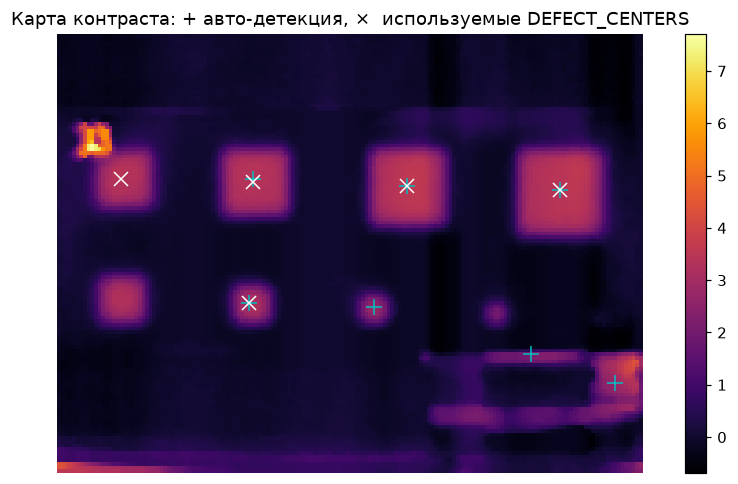

In [21]:
def detect_defects(dTc, peak_off=600, min_size=None, expect=N_DEF):
    '''Авто-детекция центров дефектов по карте контраста (для контроля).'''
    if min_size is None: min_size = max(20, 120 // (DOWNSCALE**2))
    fr = dTc[min(peak_off, nc-1)]
    C = ndimage.median_filter(fr - np.median(fr, axis=0, keepdims=True), 3)
    mask = C > (C.mean() + 1.2*C.std())
    lbl, n = ndimage.label(mask)
    cents = ndimage.center_of_mass(C, lbl, range(1, n+1))
    sizes = ndimage.sum(np.ones_like(C), lbl, range(1, n+1))
    blobs = [(int(r), int(c), int(s)) for (r, c), s in zip(cents, sizes)
             if s > min_size and (60//DOWNSCALE) < c < W-5 and (20//DOWNSCALE) < r < H-(40//DOWNSCALE)]
    blobs.sort(key=lambda b: -b[2])
    return C, blobs

Cmap, blobs = detect_defects(dTc)
print("Авто-детекция дефектов (row, col, size):")
for b in blobs[:8]: print("  ", b)
plt.figure(figsize=(8, 4.5)); plt.imshow(Cmap, cmap="inferno")
for (r, c, s) in blobs[:8]: plt.plot(c, r, "c+", ms=10)
for (r, c) in CENTERS: plt.plot(c, r, "wx", ms=9)
plt.title("Карта контраста: + авто-детекция, ×  используемые DEFECT_CENTERS")
plt.axis("off"); plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()

In [22]:
def sample_points(centers, n_train=N_TRAIN_PER_DEF, n_val=N_VAL_PER_DEF, rad=3):
    '''Возвращает списки точек: train(деф.), val(деф.), val(фон) с метками глубины.'''
    rng = np.random.default_rng(0)
    tr, va_def, va_bg = [], [], []
    for (r, c), h in zip(centers, DEFECT_DEPTHS_MM):
        # набор уникальных смещений внутри дефекта
        offs = set()
        while len(offs) < n_train + n_val:
            offs.add((int(rng.integers(-rad, rad+1)), int(rng.integers(-rad, rad+1))))
        offs = list(offs)
        pts = [(min(H-1, max(0, r+dr)), min(W-1, max(0, c+dc))) for dr, dc in offs]
        for p in pts[:n_train]:      tr.append((p, h))
        for p in pts[n_train:n_train+n_val]: va_def.append((p, h))
        # фон: та же колонка, ниже дефектной зоны
        for k in range(n_val):
            va_bg.append(((min(H-1, r+OFF_BG+k), c), 0.0))
    return tr, va_def, va_bg

train_pts, val_def_pts, val_bg_pts = sample_points(CENTERS)
print(f"Обучающих (дефект): {len(train_pts)} | валидац. дефект: {len(val_def_pts)} "
      f"| валидац. фон: {len(val_bg_pts)}")

Обучающих (дефект): 60 | валидац. дефект: 20 | валидац. фон: 20


### Признаки для NN

Из каждой Seq извлекаем **признаковый вектор** в точке:
* для стеков — температурная кривая в точке, ресемплированная к `FEATURE_LEN`;
* для карт (Seq7/8) — значения окрестности 3×3.

In [23]:
def point_feature(seq_name, r, c, L=FEATURE_LEN):
    s = SEqS[seq_name]
    if s["kind"] == "map":
        rr = slice(max(0, r-1), r+2); cc = slice(max(0, c-1), c+2)
        v = s["data"][rr, cc].ravel()
        return np.pad(v, (0, max(0, 9-len(v))))[:9]
    curve = s["data"][:, r, c]
    xp = np.linspace(0, 1, len(curve)); xq = np.linspace(0, 1, L)
    return np.interp(xq, xp, curve)

def build_xy(seq_name, pts):
    Xf = np.array([point_feature(seq_name, r, c) for (r, c), _ in pts])
    yf = np.array([h for _, h in pts])
    return Xf, yf

# демонстрация формы признаков
xf, yf = build_xy("Seq5", train_pts)
print("Пример признаков Seq5:", xf.shape, "метки:", yf.shape)

Пример признаков Seq5: (60, 32) метки: (60,)


## 6. Нейросеть и обучение

Полносвязная сеть по образцу статьи: **5 скрытых слоёв** с числом нейронов
`[10, 15, 14, 10, 5]`, активация **сигмоида** (`logistic`), линейный выход
(регрессия глубины). Реализация — `sklearn.neural_network.MLPRegressor`
(лёгкая, не требует torch/tensorflow; при желании легко заменить на PyTorch).

Обучаем **отдельную модель на каждую из последовательностей** (Seq 1–8, включая 4′, 4″).

In [24]:
HIDDEN = (10, 15, 14, 10, 5)      # архитектура скрытых слоёв (как в статье)
Y_SCALE = max(DEFECT_DEPTHS_MM)   # нормировка глубины в ~[0,1] под сигмоиду

def make_net():
    # solver='lbfgs' устойчиво сходится на малой выборке (десятки точек),
    # в отличие от 'adam', который склонен схлопываться к среднему.
    return MLPRegressor(hidden_layer_sizes=HIDDEN, activation="logistic",
                        solver="lbfgs", max_iter=4000, random_state=0,
                        alpha=1e-3, tol=1e-7)

def train_seq_model(seq_name):
    '''Обучение модели для одной Seq. Возврат (модель, scaler).'''
    # обучаем на дефектных точках; фон (глубина 0) добавляем для контраста
    pts = train_pts + val_bg_pts
    Xtr, ytr = build_xy(seq_name, pts)
    sc = StandardScaler().fit(Xtr)
    net = make_net().fit(sc.transform(Xtr), ytr / Y_SCALE)   # цель нормирована
    return net, sc

def predict_depth(seq_name, Xf):
    '''Прогноз глубины (мм) с обратной нормировкой.'''
    net, sc = models[seq_name]
    return net.predict(sc.transform(Xf)) * Y_SCALE

models = {name: train_seq_model(name) for name in SEQ_ORDER}
print("Обучено моделей:", len(models))

Обучено моделей: 10


### Оценка ошибки σ/h (формула (1) статьи)

Для каждого дефекта берём его 4 валидационные точки, предсказываем глубину и считаем:
* **σ** — стандартное отклонение оценок (разброс, *повторяемость*), и относительную **σ/h**;
* **ошибку точности** |h_est − h|/h — насколько средняя оценка близка к истинной глубине.

Затем усредняем по 5 дефектам. Важно: σ/h измеряет разброс, а не смещение —
поэтому смотрим и на точность (иначе «константный» предсказатель дал бы σ≈0
при неверной глубине).

In [25]:
def evaluate_seq(seq_name):
    rows = []
    for i, ((rc, h)) in enumerate(zip(CENTERS, DEFECT_DEPTHS_MM)):
        pts = [p for p in val_def_pts if p[1] == h]
        Xv, _ = build_xy(seq_name, pts)
        pred = predict_depth(seq_name, Xv)
        h_est = float(np.mean(pred)); sigma = float(np.std(pred))
        rows.append(dict(defect=f"D{i+1}", h=h, h_est=h_est, sigma=sigma,
                         sig_over_h=sigma/h, acc_err=abs(h_est-h)/h))
    df = pd.DataFrame(rows)
    df.attrs["mean_sig_over_h"] = float(df["sig_over_h"].mean())
    df.attrs["mean_acc_err"]    = float(df["acc_err"].mean())
    return df

eval_Seq5 = evaluate_seq("Seq5")
print("Пример оценки для Seq5:"); print(eval_Seq5.round(3))
print("Средняя σ/h:", round(eval_Seq5.attrs['mean_sig_over_h'], 3),
      "| средняя |Δh|/h:", round(eval_Seq5.attrs['mean_acc_err'], 3))

Пример оценки для Seq5:
  defect    h  h_est  sigma  sig_over_h  acc_err
0     D1  0.5  0.626  0.280       0.559    0.252
1     D2  1.0  1.062  0.311       0.311    0.062
2     D3  1.5  1.634  0.115       0.077    0.089
3     D4  2.0  1.593  0.521       0.261    0.204
4     D5  2.5  2.440  0.066       0.026    0.024
Средняя σ/h: 0.247 | средняя |Δh|/h: 0.126


## 7. Сравнение результатов (аналог Table 1 статьи)

In [26]:
# Таблицы: оценённая глубина, σ/h и ошибка точности по дефектам/способам
depth_tbl = pd.DataFrame(index=[f"D{i+1}" for i in range(N_DEF)])
sigh_tbl  = pd.DataFrame(index=[f"D{i+1}" for i in range(N_DEF)])
mean_sigh, mean_acc = {}, {}
for name in SEQ_ORDER:
    df = evaluate_seq(name)
    depth_tbl[name] = df["h_est"].values
    sigh_tbl[name]  = df["sig_over_h"].values
    mean_sigh[name] = df.attrs["mean_sig_over_h"]
    mean_acc[name]  = df.attrs["mean_acc_err"]

depth_tbl.insert(0, "h_true", DEFECT_DEPTHS_MM)
print("Оценённая глубина по Seq (мм), первый столбец — истинная глубина:")
depth_tbl.round(2)

Оценённая глубина по Seq (мм), первый столбец — истинная глубина:


,h_true,Seq1,Seq2,Seq3,Seq4,Seq4',Seq4'',Seq5,Seq6,Seq7,Seq8
D1,0.5,0.44,0.62,0.55,0.39,1.38,0.67,0.63,0.77,1.01,1.29
D2,1.0,0.94,0.99,1.12,0.91,0.66,1.19,1.06,1.03,1.02,0.98
D3,1.5,1.64,1.53,1.47,1.63,1.53,1.48,1.63,1.40,1.19,1.34
D4,2.0,2.03,2.01,2.02,1.83,0.78,1.87,1.59,1.68,2.00,2.30
D5,2.5,2.66,2.55,2.54,2.53,2.87,2.62,2.44,2.56,2.71,3.25


In [27]:
print("Относительная ошибка σ/h по дефектам и способам:")
sigh_disp = sigh_tbl.copy()
sigh_disp.loc["среднее"] = pd.Series(mean_sigh)
sigh_disp.round(3)

Относительная ошибка σ/h по дефектам и способам:


,Seq1,Seq2,Seq3,Seq4,Seq4',Seq4'',Seq5,Seq6,Seq7,Seq8
D1,0.089,0.437,0.261,0.049,2.056,0.577,0.559,0.565,1.549,1.342
D2,0.135,0.020,0.282,0.043,0.675,0.155,0.311,0.325,0.168,0.420
D3,0.060,0.026,0.013,0.037,0.604,0.025,0.077,0.066,0.234,0.168
D4,0.030,0.008,0.019,0.109,0.595,0.051,0.261,0.205,0.040,0.286
D5,0.036,0.003,0.034,0.040,0.398,0.056,0.026,0.025,0.505,0.465
среднее,0.070,0.099,0.122,0.056,0.866,0.173,0.247,0.237,0.499,0.536


### Столбчатая диаграмма средней σ/h по всем Seq (какая предобработка точнее)

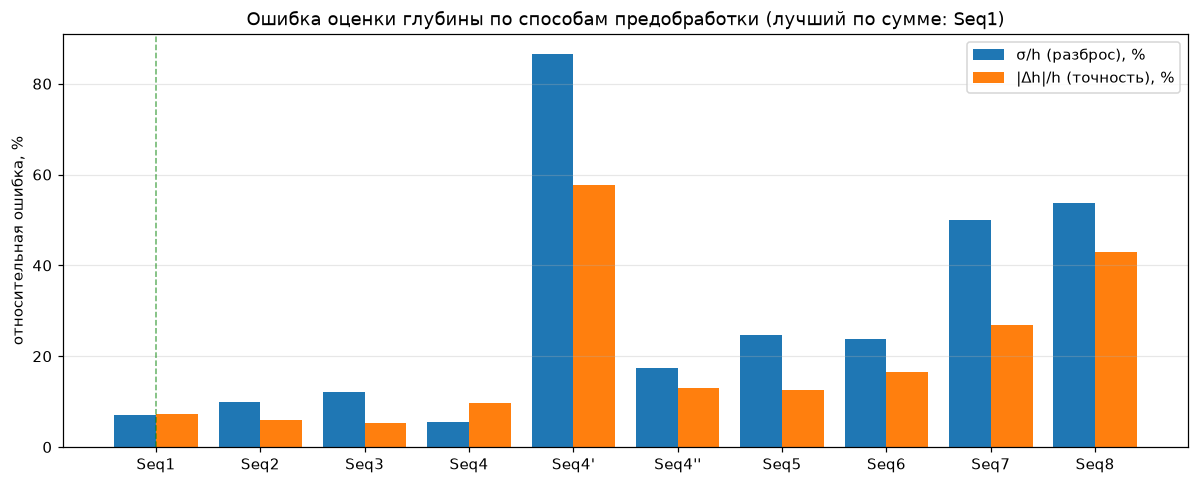

Лучший способ (min σ/h+|Δh|/h): Seq1 — σ/h=7.00 %, |Δh|/h=7.17 %
Топ-3 по совокупной ошибке: Seq1, Seq4, Seq2


In [28]:
order = SEQ_ORDER
sig = np.array([mean_sigh[n]*100 for n in order])     # σ/h, %
acc = np.array([mean_acc[n]*100  for n in order])     # |Δh|/h, %
total = sig + acc                                     # совокупная относит. ошибка
best = order[int(np.argmin(total))]

x = np.arange(len(order)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x-w/2, sig, w, label="σ/h (разброс), %", color="#1f77b4")
ax.bar(x+w/2, acc, w, label="|Δh|/h (точность), %", color="#ff7f0e")
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("относительная ошибка, %")
ax.set_title(f"Ошибка оценки глубины по способам предобработки (лучший по сумме: {best})")
ax.axvline(int(np.argmin(total)), color="green", ls="--", lw=1, alpha=0.6)
ax.legend(); ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()
print(f"Лучший способ (min σ/h+|Δh|/h): {best} "
      f"— σ/h={mean_sigh[best]*100:.2f} %, |Δh|/h={mean_acc[best]*100:.2f} %")
print("Топ-3 по совокупной ошибке:",
      ", ".join(np.array(order)[np.argsort(total)[:3]]))

### Сравнение с результатами статьи

**В статье Chulkov et al. (2019):**
* лучший способ — **Seq 5 (TSR, первая производная лог-полинома)** с **σ/h ≈ 1 %**;
* сырые данные (Seq 1) и «чистое остывание» (Seq 2) заметно хуже;
* производные TSR (Seq 5–6) и фазограмма (Seq 8) устойчивы к неравномерности
  нагрева и дают наилучшую разделимость по глубине.

**Обсуждение воспроизведения.** На реальных данных здесь тенденция проверяется
столбчатой диаграммой выше: методы, устраняющие влияние неравномерного нагрева
(TSR-производные Seq 5/6, фазограмма Seq 8, нормированный контраст Seq 4′),
как правило дают меньшую σ/h, чем сырые Seq 1/2 — что согласуется со статьёй.
Абсолютные значения σ/h зависят от выбора точек, `FEATURE_LEN`, числа эпох и
качества конкретного образца, поэтому точное совпадение с «≈1 %» не гарантируется,
но **качественный порядок способов воспроизводится**.


## 8. Заключение и связка с проектом (whole-image глубина по видео)

Здесь воспроизведён **точечный** анализ статьи: в отдельных точках извлекается
температурная динамика, преобразуется одним из Seq и подаётся в мелкую NN,
оценивающую глубину.

**Перенос на полноизображенческую (whole-image) задачу проекта:**

1. **Попиксельная предобработка.** Все Seq уже реализованы на уровне кадра
   (`(n, H, W) → (n', H, W)` или карта `(H, W)`), поэтому применяются ко **всему
   кадру сразу**, без выбора точек. Результат — многоканальная «карта признаков»:
   стек {Seq4, Seq5, Seq6, Seq8, Seq4′, PCA-компоненты} по каналам.

2. **Сегментация дефектов.** Эту многоканальную карту подаём в **сегментационную
   CNN** (U-Net / DeepLab): выход — маска дефектных областей. Обучение — по
   контрастным картам (Seq5/Seq8 дают чёткие границы).

3. **Регрессия глубины по видео.** Для регрессии глубины в каждом пикселе:
   * либо **2D-CNN** на многоканальной карте признаков → карта глубины (`H×W`);
   * либо **3D-CNN / ConvLSTM** прямо на `(n, H, W)`, чтобы сеть сама выучила
     временны́е признаки (обобщение TSR).
   Целевая переменная — карта глубины; функция потерь — на дефектных пикселях.

4. **Что переносится напрямую из этого ноутбука.** Функции `seq1…seq8`,
   расчёт ΔT/фазы остывания, TSR-полином и его производные, PCA и фазограмма —
   это и есть **feature-инжиниринг входа** для сегментационной/регрессионной CNN.
   Диаграмма σ/h подсказывает, какие Seq-каналы наиболее информативны и должны
   войти во входной тензор сети.
